# Denoising Diffusion Implicit Models (DDIM)

In this tutorial, we will create and train a **conditional** [Denoising Diffusion Implicit Models (DDIM)](https://arxiv.org/abs/2010.02502) using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) API, a diffusion library built on top of the [PyTorch](https://pytorch.org/) API. Note that this tutorial will not train a model in real-time; instead, it will demonstrate how to train a DDPM model using the TorchDiff API.

<br>
<div align="center">
  <img src="https://raw.githubusercontent.com/LoqmanSamani/TorchDiff/systembiology/imgs/ddim.png" alt="UnCLIP overview" width="1200"/>
  <br>
  <em>An overview of the DDIM pipeline, adapted from the original paper.</em>
  <br><br>
</div>

---

## Table of Contents

- [Data Preparation](#data-preparation)
- [Training a DDIM Model](#training-a-ddim-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

## Data Preparation

For this tutorial, we will use the [CIFAR10](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) dataset from [Torchvision](https://pytorch.org/vision/stable/).

In [2]:
# Import all necessary libraries and modules for training a DDPM model
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
# Import required classes from the DDIM module of TorchDiff
from torchdiff.ddim import VarianceSchedulerDDIM, ReverseDDIM, ForwardDDIM, TrainDDIM, SampleDDIM
# Import utility functions from the TorchDiff utils module
from torchdiff.utils import TextEncoder, NoisePredictor, Metrics

## Downloading the CIFAR10 Dataset from Torchvision

In this section, we will download the [CIFAR10](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) dataset using the [Torchvision](https://pytorch.org/vision/stable/) library.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # For RGB
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [00:14<00:00, 11.6MB/s]


### Using a Subset of the CIFAR10 Dataset

This tutorial will use a small subset of the CIFAR10 dataset for training and validation. Specifically, we will select 100 images for training and 10 images for validation to demonstrate the training process of the DDIM model.

In [4]:
# Use small subset
train_subset = Subset(train_dataset, torch.randperm(len(train_dataset))[:100])
test_subset = Subset(test_dataset, torch.randperm(len(test_dataset))[:20])

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_subset, batch_size=10, shuffle=False)

### Visualizing Training Images

In this section, we will visualize a few images from the training subset.

In [5]:
# CIFAR-10 class names
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']

def denormalize(tensor):
    """Convert tensor from [-1, 1] back to [0, 1] for display"""
    return tensor * 0.5 + 0.5

def visualize_cifar10_grid(dataloader, num_images=64):
    """
    Visualize CIFAR-10 images in an 8x8 grid with labels
    """
    # Get one batch of images
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    # If batch is smaller than 64, get more batches
    all_images = images
    all_labels = labels
    
    while len(all_images) < num_images:
        try:
            images, labels = next(dataiter)
            all_images = torch.cat([all_images, images])
            all_labels = torch.cat([all_labels, labels])
        except StopIteration:
            # If we run out of data, break
            break
    
    # Take only the first 64 images
    all_images = all_images[:num_images]
    all_labels = all_labels[:num_images]
    
    # Create figure
    fig, axes = plt.subplots(8, 8, figsize=(8, 8))
    fig.suptitle('CIFAR-10 Dataset Sample (8x8 Grid)', fontsize=12)
    
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            if idx < len(all_images):
                # Denormalize and convert to numpy
                img = denormalize(all_images[idx])
                img = img.permute(1, 2, 0)  # Change from CHW to HWC
                img = torch.clamp(img, 0, 1)  # Ensure values are in [0, 1]
                
                # Display image
                axes[i, j].imshow(img)
                axes[i, j].set_title(f'{cifar10_classes[all_labels[idx]]}', fontsize=10)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

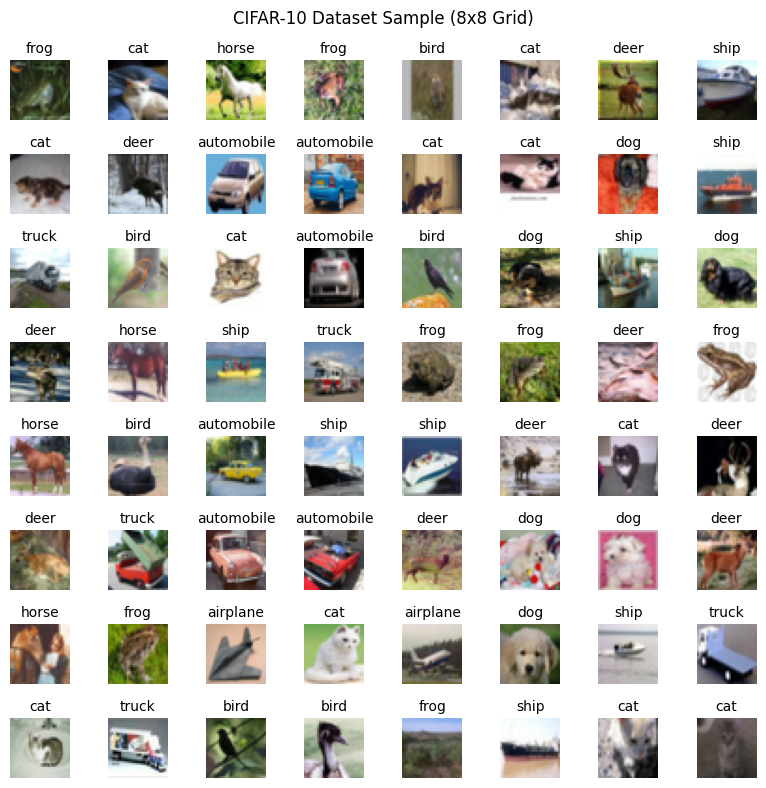

In [6]:
visualize_cifar10_grid(train_loader)

### Considerations for Dataset and Scalability

The subset of data which we chose to train is small and not proper to train a diffusion model. However, the focus here is to demonstrate how to use the TorchDiff API. You can scale up the training dataset or switch to more realistic, high-resolution, RGB images based on your specific needs.

## Training Process for the DDIM Model

Before training a Denoising Diffusion Implicit Models (DDIM), we need to prepare several key components required for the training process:

- **Noise Predictor ([torchdiff.utils.NoisePredictor](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.NoisePredictor))**:
  This module predicts the amount of noise added to the data and uses this prediction to denoise the data during the backward pass of the diffusion process. For more details, refer to the [TorchDiff NoisePredictor documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.NoisePredictor).

- **TextEncoder ([torchdiff.utils.TextEncoder](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.TextEncoder))**: Transformer-based encoder for text prompts or image labels in conditional diffusion models. For more details, refer to the [TorchDiff TextEncoder documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.TextEncoder). 

- **Optimizer ([torch.optim.AdamW](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW))**:
  For training the DDPM model, we use the AdamW optimizer, which is well-suited for optimizing neural networks.

- **Loss Function ([torch.nn.MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html))**:
  This tutorial employs a simple Mean Squared Error (MSE) loss from PyTorch, which computes the difference between the predicted noise (from the NoisePredictor) and the actual noise added during the forward pass.

- **Metrics ([torchdiff.utils.Metrics](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.Metrics))**:
  This class from the TorchDiff library computes various evaluation metrics based on the specified requirements. The following metrics are supported:
  - Fréchet Inception Distance (FID) (if `fid=True`).
  - Learned Perceptual Image Patch Similarity (LPIPS) (if `lpips=True`).
  - A set of three metrics: Mean Squared Error (MSE), Peak Signal-to-Noise Ratio (PSNR), and Structural Similarity Index (SSIM) (if `metrics=True`).
  For more details, refer to the [TorchDiff Metrics documentation](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.Metrics).

In [7]:
# Initialize the NoisePredictor for the DDIM model with parameters for RBG images
noise_predictor = NoisePredictor(
    in_channels=3,  # RBG images
    down_channels=[16, 32],
    mid_channels=[32, 32], 
    up_channels=[32, 16],
    down_sampling=[True, True],
    time_embed_dim=32,
    y_embed_dim=32,
    num_down_blocks=2,
    num_mid_blocks=2,
    num_up_blocks=2,
    down_sampling_factor=2
)

# label conditional model
text_encoder = TextEncoder(
    use_pretrained_model=True,
    model_name="bert-base-uncased",
    vocabulary_size=30522,
    num_layers=2,
    input_dimension=32,
    output_dimension=32,
    num_heads=2,
    context_length=77
)

# Set up the AdamW optimizer for the NoisePredictor parameters plus TextEncoder trainable parameters with a learning rate of 1e-3
optimizer = torch.optim.Adam(
    [p for p in noise_predictor.parameters() if p.requires_grad] +
    [p for p in text_encoder.parameters() if p.requires_grad], lr=1e-4
)

# Initialize the Mean Squared Error (MSE) loss function
loss = nn.MSELoss()

# Configure the Metrics class for evaluation on CPU (GPUs are recommended for actual training)
metrics = Metrics(
    device="cpu",  # Using CPU for this tutorial, but GPUs are recommended for training diffusion models
    fid=True, 
    metrics=True, 
    lpips_=True
)

### Required TorchDiff DDIM Classes for Training

To train the DDIM model, this tutorial requires the following specific classes from the TorchDiff DDIM module:

- **DDIM VarianceScheduler ([VarianceSchedulerDDIM](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.VarianceSchedulerDDIM))**:
  This class manages the noise schedule for the DDIM model. For more details, refer to the [TorchDiff VariancdSchedulerDDIM documentation](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.VarianceSchedulerDDIM).

- **Reverse Diffusion ([ReverseDDIM](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.ReverseDDIM))**:
  This class is used during the sampling process to perform reverse diffusion. For more details, refer to the [TorchDiff ReverseDDIM documentation](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.ReverseDDIM).

- **DDIM Trainer ([TrainDDIM](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.TrainDDIM))**:
  This class handles the training of the prepared DDIM model. For more details, refer to the [TorchDiff TrainDDIM documentation](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.TrainDDIM).

In [8]:
# Initialize DDIM varinace-scheduler for the noise schedule
variance_scheduler_ddim = VarianceSchedulerDDIM(
    num_steps=500, # number of steps during training
    tau_num_steps=100, # number of steps during sampling
    beta_start=1e-4, 
    beta_end=0.02, 
    beta_method="linear"
)

# Set up the reverse diffusion process for sampling
forward_ddim = ForwardDDIM(variance_scheduler_ddim)
reverse_ddim = ReverseDDIM(variance_scheduler_ddim)

# Configure the DDIM trainer for model training
train_ddim = TrainDDIM(
    noise_predictor=noise_predictor,
    forward_diffusion=forward_ddim,
    reverse_diffusion=reverse_ddim,
    data_loader=train_loader,
    optimizer=optimizer,
    objective=loss,
    val_loader=val_loader, 
    max_epochs=10,
    device="cpu",
    conditional_model=text_encoder,
    metrics_=metrics,
    bert_tokenizer=None,
    max_token_length=77,
    store_path="ddim_test",
    patience=10,
    warmup_epochs=2,
    val_frequency=5,
    image_output_range=(-1, 1),
    normalize_output=True,
    use_ddp=False, # Enable if using multiple GPUs
    grad_accumulation_steps=1,
    log_frequency=1,
    use_compilation=False # Disable model compilation (not required here)
)

In [9]:
# Count total parameters in the trainer
num_params = sum(param.numel() for param in train_ddim.parameters())
print(f"Number of parameters in the ddim model: {num_params:,}")

Number of parameters in the ddim model: 109,666,211


In [10]:
# start trining
train_losses, best_val_loss = train_ddim()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:22<00:00,  5.72s/it]



Epoch: 1/10 | LR: 1.00e-04 | Train Loss: 1.2312



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:22<00:00,  5.63s/it]



Epoch: 2/10 | LR: 1.00e-04 | Train Loss: 1.1832



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:23<00:00,  5.75s/it]


...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.42s/it]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.37s/it]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.57s/it]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.34s/it]


 | Val Loss: 0.7865 | FID: 488.4381 | MSE: 0.2967 | PSNR: 5.2799 | SSIM: 0.0505 | LPIPS: 0.7082
Model saved at epoch 10


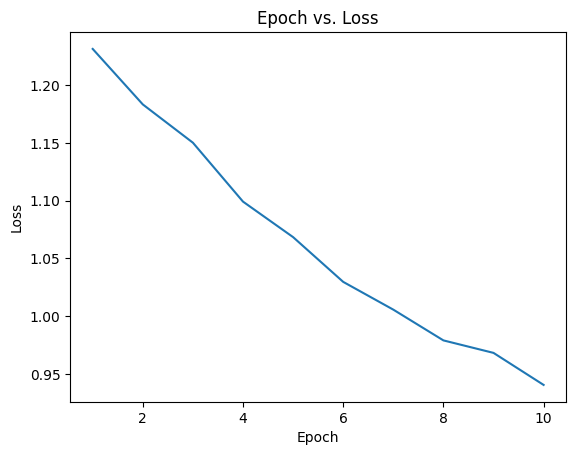

In [11]:
plt.plot([i for i in range(1, 11)], train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs. Loss")
plt.show()

## Sampling Process for the DDIM Model

After training the DDIM model, we can generate new images. While we can directly use the trained model, it is common to load the trained parameters of the denoising model and generate new data using the [torchdiff.ddim.SampleDDIM](https://torchdiff.readthedocs.io/en/latest/ddim.html#torchdiff.ddim.SampleDDIM) class. In this tutorial, we will load the trained parameters and generate new images.

In [12]:
# Initialize a new NoisePredictor with the same architecture as the trained model
new_noise_predictor = NoisePredictor(
    in_channels=3,  # RBG images
    down_channels=[16, 32],
    mid_channels=[32, 32], 
    up_channels=[32, 16],
    down_sampling=[True, True],
    time_embed_dim=32,
    y_embed_dim=32,
    num_down_blocks=2,
    num_mid_blocks=2,
    num_up_blocks=2,
    down_sampling_factor=2
)

# label conditional model
new_text_encoder = TextEncoder(
    use_pretrained_model=True,
    model_name="bert-base-uncased",
    vocabulary_size=30522,
    num_layers=2,
    input_dimension=32,
    output_dimension=32,
    num_heads=2,
    context_length=77
)

# Initialize DDIM varinace-scheduler for the noise schedule
new_variance_scheduler_ddim = VarianceSchedulerDDIM(
    num_steps=500, # number of steps during training
    tau_num_steps=100, # number of steps during sampling
    beta_start=1e-4, 
    beta_end=0.02, 
    beta_method="linear"
)

# Set up the reverse diffusion process for sampling
new_reverse_ddim = ReverseDDIM(new_variance_scheduler_ddim)


# Load the trained model checkpoint from file
checkpoint = torch.load('ddim_test/ddim_epoch_10.pth', map_location='cpu')

# Load the trained parameters into the new NoisePredictor and set to evaluation mode
new_noise_predictor.load_state_dict(checkpoint['model_state_dict_noise_predictor'])
new_noise_predictor.eval()
# Print the total number of parameters in the NoisePredictor
print("Number of NoisePredictor's parameters:")
print(sum(p.numel() for p in new_noise_predictor.parameters()))

# Load the trained parameters into the new TextEncoder and set to evaluation mode
new_text_encoder.load_state_dict(checkpoint['model_state_dict_conditional'])
new_text_encoder.eval()
# Print the total  number of parameters in the NoisePredictor
print("Number of TextEncoder's parameters:")
print(sum(p.numel() for p in new_text_encoder.parameters()))

new_reverse_ddim.variance_scheduler.load_state_dict(checkpoint['variance_scheduler_model'])

Number of NoisePredictor's parameters:
159363
Number of TextEncoder's parameters:
109506848


<All keys matched successfully>

In [13]:
# sampling process
sampler = SampleDDIM(
    reverse_diffusion=new_reverse_ddim,
    noise_predictor=new_noise_predictor,
    image_shape=(32, 32),
    conditional_model=new_text_encoder,
    bert_tokenizer="bert-base-uncased",
    max_token_length=77,
    batch_size=10, # generate 10 new images
    in_channels=3,
    device="cpu",
    image_output_range=(-1, 1)
)

In [14]:
gen_imgs = sampler(
    conditions=['airplane', 'automobile', 'bird', 'cat', 'deer', 
                'dog', 'frog', 'horse', 'ship', 'truck'], # 10 lables as conditions
    save_images=True,
    save_path="ddim_generated"
) # the created images will be stored in the given directory

### Visualizing Generated Images

In this section, we will visualize the images generated by the trained DDIM model to inspect the results of the sampling process.

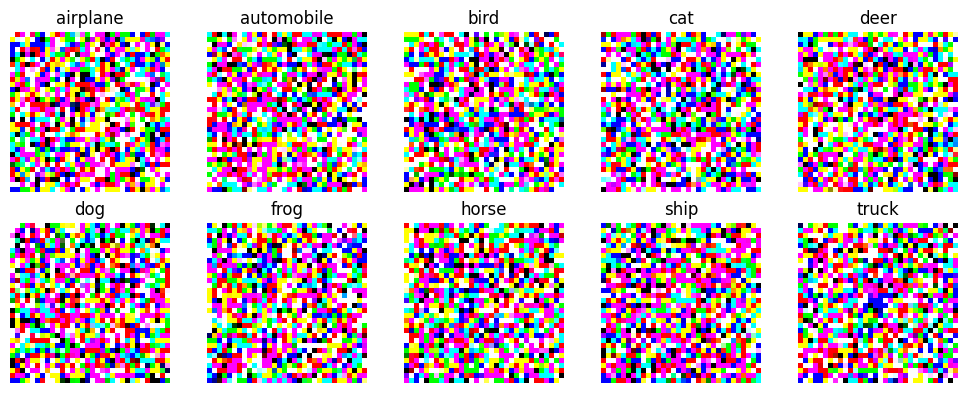

In [15]:
folder_path = "ddim_generated"
conditions=['airplane', 'automobile', 'bird', 'cat', 'deer', 
            'dog', 'frog', 'horse', 'ship', 'truck']
num_images = 10 
rows, cols = 2, 5

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

for i in range(num_images):
    img_path = os.path.join(folder_path, f"image_{i+1}.png")
    img = Image.open(img_path).convert('RGB') 

    ax = axes[i // cols, i % cols]
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(conditions[i])

plt.tight_layout()
plt.show()

### Evaluating the Generated Images

The generated images may not be optimal, as we trained a shallow DDIM model for only 10 epochs on a small subset of the CIFAR10 dataset. This limited training setup is intended to demonstrate the TorchDiff API rather than achieve high-quality results.

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502)